# TT3 — Gaussian energy distributions

Fit population mean and standard deviation to labeled TRAIN normalized STE, then solve the equal-Gaussian-density threshold.

This notebook contains all computation for one student's algorithm. Run the cells in order with Python 3, matplotlib and IPython. WAV/LAB input is supplied separately in `data/train/` and `data/test/`; edit `DATA_DIR` if needed. The notebook discovers these folders from its working directory and ancestors.

The signal is framed with full 25 ms windows and 10 ms hops, using Python's nearest-sample rounding with ties to even. Energy is STE divided by frame size. Final regions require HIGH confirmation, continue above LOW, merge internal silence shorter than 200 ms and discard speech shorter than 100 ms. Training and test results are labeled separately. Every number and plot below is recomputed from input WAV/LAB; no saved model or result is loaded.

Before submission, use **Restart Kernel and Run All** and save the executed notebook so numeric tables and all plots remain visible. Submit this `.ipynb` without bundling WAV or other signal files.


## Imports and fixed configuration

Only the standard library, matplotlib and IPython are used. Timing and endpoint rules are fixed.


In [1]:
import math
import wave
import hashlib
import html
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import HTML, display

ALGORITHM = 'tt3'
FRAME_MS = 25.0
HOP_MS = 10.0
SAMPLE_ROUNDING = "nearest_integer_samples_python_round_ties_to_even"
MIN_SILENCE_SECONDS = 0.200
MIN_SPEECH_SECONDS = 0.100
BOUNDARY_TOLERANCE_SECONDS = 0.100
HISTOGRAM_W_TIE_PREFERENCE = 20.0
PADDING_MS = 250.0
PADDING_FRAMES = round(PADDING_MS / HOP_MS)
FILE_ORDER = ("phone_F2", "phone_M2", "studio_F2", "studio_M2")

# Optional: edit this to the folder containing train/ and test/.
# None discovers data/ from the working directory and its ancestors.
DATA_DIR = None
plt.rcParams.update({"figure.dpi": 115, "font.size": 10})


## WAV and LAB input

PCM decoding and interval validation are manual. `sil=0`; `v` and `uv` are speech. Optional Praat metadata lines are ignored after format validation.


In [2]:
def read_wav(path):
    """Đọc WAV PCM nguyên và chuyển các kênh thành waveform mono.

    Đầu vào: path là đường dẫn WAV PCM 8/16/24/32 bit không nén.
    Đầu ra: Tuple (samples, fs): list float chia toàn thang PCM và tần số mẫu Hz từ header.

    Các mẫu trả về được chia cho toàn thang PCM, không chuẩn hóa theo đỉnh.
    Với PCM 8 bit, dữ liệu không dấu được dịch về tâm 0 trước khi chia.
    Tần số mẫu lấy trực tiếp từ header; WAV nén bị từ chối rõ ràng.
    """
    # Header xác định Fs, số kênh và số byte mỗi mẫu.
    # Chỉ nhận PCM nguyên không nén để giải mã từng byte rõ ràng.
    # PCM 8 bit không dấu được dịch về tâm 0; các độ rộng khác có dấu.
    # Chia toàn thang PCM rồi lấy trung bình các kênh tại cùng thời điểm.
    # Không chuẩn hóa theo đỉnh waveform; STE được chuẩn hóa ở features.
    with wave.open(str(path), "rb") as source:
        channels, width = source.getnchannels(), source.getsampwidth()
        fs = source.getframerate()
        if source.getcomptype() != "NONE" or width not in (1, 2, 3, 4):
            raise ValueError(f"WAV cần PCM nguyên 8/16/24/32 bit: {path}")
        raw = source.readframes(source.getnframes())
    samples = []
    scale = float(1 << (width * 8 - 1))
    # Một frame WAV chứa lần lượt một mẫu của mỗi kênh.
    # Chuyển PCM sang float trước khi trộn để giữ toàn thang [-1, 1).
    for offset in range(0, len(raw), width * channels):
        total = 0.0
        for channel in range(channels):
            index = offset + channel * width
            block = raw[index:index + width]
            value = block[0] - 128 if width == 1 else int.from_bytes(block, "little", signed=True)
            total += value / scale
        samples.append(total / channels)
    return samples, fs


def read_lab(path, duration):
    """Đọc, kiểm tra và chặn các khoảng nhãn theo thời lượng WAV.

    Đầu vào: path là đường dẫn LAB; duration là thời lượng WAV dương, hữu hạn theo giây.
    Đầu ra: List (start, end, label) theo giây với label sil/v/uv; lỗi ghi rõ dòng nguồn.

    Nhãn hợp lệ là sil, v, uv; lỗi dữ liệu báo kèm số dòng, không bị nuốt.
    Kiểm tra thứ tự và đoạn chồng lấn trước khi chặn biên theo WAV.
    Sai lệch cuối tối đa 10 ms được chấp nhận do LAB làm tròn 2 chữ số.
    Khoảng âm thanh ngoài nhãn không tự được gán thành khoảng lặng.
    """
    # Thời lượng WAV phải hợp lệ trước khi kiểm tra nhãn.
    # Bỏ dòng trắng và chỉ hai dạng thống kê F0 được quy định.
    # Mỗi đoạn phải có đủ start/end/nhãn và thứ tự không chồng lấn.
    # LAB có thể làm tròn đuôi trong 10 ms, sau đó chặn END theo WAV.
    # Khoảng không được LAB phủ vẫn thiếu nhãn, không tự thêm silence.
    if not math.isfinite(duration) or duration <= 0:
        raise ValueError("Thời lượng WAV phải dương và hữu hạn")
    path = Path(path)
    intervals, previous_end = [], 0.0
    # Không suy luận nhãn từ dòng lỗi: mỗi lỗi phải được phát hiện tại nguồn.
    with path.open(encoding="utf-8-sig") as source:
        for number, line in enumerate(source, 1):
            columns = line.split()
            if not columns:
                continue
            error = f"{path.name}, dòng {number}: LAB không hợp lệ"
            if columns[0] in ("F0mean", "F0std"):
                # Hai dòng F0 là thống kê Praat; kiểm tra định dạng rồi bỏ qua.
                if len(columns) != 2:
                    raise ValueError(error)
                try:
                    value = float(columns[1])
                except ValueError as exc:
                    raise ValueError(error) from exc
                if not math.isfinite(value) or value < 0:
                    raise ValueError(error)
                continue
            if len(columns) != 3 or columns[2] not in ("sil", "v", "uv"):
                raise ValueError(error)
            try:
                start, end = float(columns[0]), float(columns[1])
            except ValueError as exc:
                raise ValueError(error) from exc
            # Kiểm tra số, thứ tự và thời lượng trước khi chặn sai lệch làm tròn.
            if (not math.isfinite(start) or not math.isfinite(end)
                    or start < 0 or end <= start or start < previous_end - 1e-9
                    or end > duration + 0.010001):
                raise ValueError(error)
            previous_end = end
            end = min(end, duration)
            if start < end:
                intervals.append((start, end, columns[2]))
    if not intervals:
        raise ValueError(f"{path.name}: không có đoạn nhãn")
    return intervals


In [3]:
def find_data_root(data_dir=None):
    """Resolve a dataset supplied separately from this notebook."""
    if data_dir is not None:
        requested = Path(data_dir).expanduser().resolve()
        candidates = [requested, requested / "data"]
    else:
        current = Path.cwd().resolve()
        candidates = []
        for directory in (current, *current.parents):
            candidates.extend([directory / "data", directory])
    for candidate in candidates:
        if (candidate / "train").is_dir() and (candidate / "test").is_dir():
            return candidate
    raise FileNotFoundError(
        "Place the teacher's WAV/LAB pairs in data/train and data/test, "
        "or set DATA_DIR to the folder containing train and test."
    )


def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for block in iter(lambda: handle.read(65536), b""):
            digest.update(block)
    return digest.hexdigest()


def load_dataset_folder(data_root, split):
    paths = sorted((data_root / split).glob("*.wav"))
    if len(paths) != 4:
        raise FileNotFoundError(f"Expected four WAV/LAB pairs in the {split} split.")
    records = []
    for path in paths:
        lab_path = path.with_suffix(".lab")
        if not lab_path.is_file():
            raise FileNotFoundError(f"Missing matching LAB for {path.name}")
        samples, fs = read_wav(path)
        duration = len(samples) / fs
        records.append(dict(name=path.stem, split=split, wav_path=str(path),
                            samples=samples, sample_rate=fs, duration=duration,
                            intervals=read_lab(lab_path, duration),
                            wav_sha256=file_sha256(path), lab_sha256=file_sha256(lab_path)))
    return records


def display_table(rows, columns, caption):
    """Render compact rows without dependencies on pandas or project code."""
    def format_value(value):
        if value is None:
            return "N/A"
        if isinstance(value, float):
            return f"{value:.9g}"
        return str(value)
    pieces = ["<table style='border-collapse:collapse;font-size:13px'>",
              "<caption style='text-align:left;font-weight:bold;margin:10px 0'>"
              + html.escape(caption) + "</caption><thead><tr>"]
    for key, label in columns:
        pieces.append("<th style='padding:5px 9px;border-bottom:2px solid #888;text-align:left'>"
                      + html.escape(label) + "</th>")
    pieces.append("</tr></thead><tbody>")
    for row in rows:
        pieces.append("<tr>")
        for key, _ in columns:
            pieces.append("<td style='padding:5px 9px;border-bottom:1px solid #ddd'>"
                          + html.escape(format_value(row.get(key))) + "</td>")
        pieces.append("</tr>")
    pieces.append("</tbody></table>")
    display(HTML("".join(pieces)))


## Manual frame features

Each full frame computes STE and mean absolute amplitude by sample loops. Normalization divides by the recording's maximum; an all-zero recording stays zero. The short tail is discarded.


In [4]:
def normalize_max(values):
    """Chuẩn hóa chuỗi không âm theo đỉnh của chính bản ghi.

    Input: values là năng lượng/biên độ không âm. Output: list cùng độ dài
    đã chia max; chuỗi không có đỉnh dương trả toàn 0, không sửa input.
    """
    peak = 0.0
    for value in values:
        if value > peak:
            peak = value
    return [value / peak for value in values] if peak > 0 else [0.0 for _ in values]


def compute_features(samples, fs, frame_ms=FRAME_MS, hop_ms=HOP_MS):
    """Chia khung đầy đủ theo số mẫu, bỏ đuôi ngắn hơn một khung.

    starts/ends là miền hỗ trợ khung; centers là tâm miền hỗ trợ đó.
    Chỉ giữ start + frame_size <= len(samples), không thêm 0 ở đuôi WAV.
    Tín hiệu ngắn hơn một khung bị từ chối để tránh lệch thống kê năng lượng.
    STE là tổng bình phương, energy là trung bình bình phương, MA là meanabs.
    Các đặc trưng normalized dùng đỉnh riêng của từng bản ghi WAV.

    Input: samples là waveform mono, fs là Hz; frame_ms/hop_ms là thời gian
    yêu cầu. Output: dict chuỗi
    đặc trưng và timing; frame_ms/hop_ms phản ánh số mẫu thật đã làm tròn,
    requested_* giữ thời gian yêu cầu, frame_size/hop_size là số mẫu nguyên.
    round(fs*ms/1000) chọn mẫu gần nhất, tie .5 dùng số chẵn của Python.
    """
    if fs <= 0 or frame_ms <= 0 or hop_ms <= 0:
        raise ValueError("Tần số mẫu, độ dài khung và bước khung phải dương")
    frame_size = max(1, int(round(fs * frame_ms / 1000)))
    hop_size = max(1, int(round(fs * hop_ms / 1000)))
    if hop_size > frame_size:
        raise ValueError("Bước khung không được lớn hơn độ dài khung")
    if 0 < len(samples) < frame_size:
        raise ValueError("Tín hiệu ngắn hơn một khung đầy đủ")
    features = {key: [] for key in ("starts", "centers", "ends", "ste", "energy", "ma")}
    for start in range(0, len(samples) - frame_size + 1, hop_size):
        # Tính trực tiếp trên các mẫu thật, với hai tổng độc lập STE và MA.
        end = start + frame_size
        squared, absolute = 0.0, 0.0
        for index in range(start, end):
            value = samples[index]
            squared += value * value
            absolute += abs(value)
        # Đổi chỉ số mẫu sang giây sau khi tính, tránh tích lũy sai số bước nhảy.
        features["starts"].append(start / fs)
        features["ends"].append(end / fs)
        features["centers"].append((start + end) / (2 * fs))
        features["ste"].append(squared)
        features["energy"].append(squared / (end - start))
        features["ma"].append(absolute / (end - start))
    # Giữ raw và normalized song song để plot và từng thuật toán dùng đúng đơn vị.
    features["ste_norm"] = normalize_max(features["ste"])
    features["ma_norm"] = normalize_max(features["ma"])
    features.update(frame_ms=frame_size / fs * 1000, hop_ms=hop_size / fs * 1000,
                    requested_frame_ms=float(frame_ms), requested_hop_ms=float(hop_ms),
                    frame_size=frame_size, hop_size=hop_size, sample_rate_hz=fs,
                    sample_rounding=SAMPLE_ROUNDING)
    return features


## LAB alignment and scoring

LAB labels use the frame center and half-open intervals. Region MAE/RMSE score START and END of complete matched final regions. A missing or extra region leaves the primary MAE undefined; frame and tolerance-based boundary scores are additional diagnostics.


For multiple speech regions, "outer" refers to each final region's START/END; the metric does not collapse regions into a single global envelope.

In [5]:
def frame_labels(centers, intervals):
    """Gán nhãn chuẩn cho mỗi tâm khung bằng các khoảng LAB.

    Đầu vào: centers là tâm khung theo giây tăng dần; intervals là LAB theo thứ tự thời gian.
    Đầu ra: List 0 cho sil, 1 cho v/uv, None ngoài nhãn; dùng khoảng nửa mở [start, end).

    sil cho 0, v/uv cho 1; ngoài phạm vi nhãn cho None.
    Các tâm và đoạn phải theo thứ tự thời gian để quét tuyến tính.
    """
    # Tâm khung và LAB được duyệt theo thứ tự thời gian.
    # Con trỏ chỉ tiến qua các đoạn đã kết thúc để giữ chi phí tuyến tính.
    # Khoảng [start,end) làm tâm đúng END thuộc đoạn tiếp theo.
    # Silence nhận 0, v/uv nhận 1 vì đều là speech.
    # Tâm ngoài LAB nhận None để không đưa nhãn giả vào train/metric.
    labels, cursor = [], 0
    # Con trỏ chỉ đi tới: bỏ các đoạn đã hết trước khi gán nhãn cho tâm khung.
    for center in centers:
        while cursor < len(intervals) and center >= intervals[cursor][1]:
            cursor += 1
        if cursor < len(intervals) and intervals[cursor][0] <= center < intervals[cursor][1]:
            labels.append(0 if intervals[cursor][2] == "sil" else 1)
        else:
            labels.append(None)
    return labels


def frame_metrics(labels, mask):
    """Tính confusion matrix và accuracy/precision/recall/F1 theo khung.

    Đầu vào: labels là list 0/1/None; mask là list 0/1 dự đoán cùng độ dài.
    Đầu ra: Dict TP/TN/FP/FN, ignored/evaluated và các tỷ lệ; bỏ None khỏi mẫu số.
    """
    # Độ dài phải khớp để mỗi prediction có một nhãn chuẩn.
    # Kiểm tra miền nhãn trước khi tính confusion matrix.
    # None tăng ignored và không tham gia các mẫu số.
    # TP/FP dựa vào dự đoán speech; TN/FN dựa vào dự đoán silence.
    # Mẫu số precision/recall bằng 0 cho tỷ lệ 0; không có nhãn cho accuracy None.
    if len(labels) != len(mask):
        raise ValueError("Số nhãn chuẩn và dự đoán phải bằng nhau")
    counts = {"tp": 0, "tn": 0, "fp": 0, "fn": 0, "ignored": 0}
    # None không tham gia mẫu số; frame có nhãn phải được tính dù dự đoán sai.
    for label, predicted in zip(labels, mask):
        if predicted not in (0, 1) or label not in (0, 1, None):
            raise ValueError("Nhãn phải là 0, 1 hoặc None cho LAB ngoài phạm vi")
        if label is None:
            counts["ignored"] += 1
            continue
        key = ("t" if label == predicted else "f") + ("p" if predicted else "n")
        counts[key] += 1
    total = counts["tp"] + counts["tn"] + counts["fp"] + counts["fn"]
    # Precision lấy trên dự đoán speech, recall lấy trên speech của LAB.
    precision_denominator = counts["tp"] + counts["fp"]
    recall_denominator = counts["tp"] + counts["fn"]
    precision = counts["tp"] / precision_denominator if precision_denominator else 0.0
    recall = counts["tp"] / recall_denominator if recall_denominator else 0.0
    return {**counts, "evaluated": total, "accuracy": (counts["tp"] + counts["tn"]) / total if total else None,
            "precision": precision, "recall": recall,
            "f1": 2 * precision * recall / (precision + recall) if precision + recall else 0.0}


def ground_truth_regions(intervals):
    """Đầu vào: LAB intervals. Đầu ra: vùng nói chuẩn; chỉ gộp v/uv tiếp giáp.

    Silence được ghi rõ trong LAB vẫn là khoảng phân cách; không xoá nhãn chuẩn.
    """
    regions=[]
    for start,end,label in intervals:
        if label not in ('v','uv'):continue
        if regions and abs(start-regions[-1][1])<=1e-9:
            regions[-1]=(regions[-1][0],end)
        else:regions.append((start,end))
    return regions


def region_endpoint_metrics(reference,predicted):
    """Đầu vào: các FINAL vùng chuẩn/dự đoán tăng dần, đơn vị giây.

    Đầu ra: MAE/RMSE trên start/end của các cặp vùng, counts và status.
    DP ghép theo thời gian, ưu tiên số cặp overlap rồi tổng lỗi nhỏ nhất.
    Cùng số vùng: ghép theo thứ tự và tính cả lỗi không overlap.
    Thiếu/thừa vùng: MAE chính=None; matched MAE riêng để không che vùng sai.
    """
    for regions in (reference,predicted):
        previous=-1.
        for start,end in regions:
            if not(math.isfinite(start) and math.isfinite(end) and 0<=start<end and start>=previous):
                raise ValueError('Regions must be finite, ordered and nonoverlapping')
            previous=end
    nr,np=len(reference),len(predicted)
    score=[[(0,0.) for _ in range(np+1)] for _ in range(nr+1)]
    action=[[0]*np for _ in range(nr)]
    # Match complete regions, never individual starts to ends or debug candidates.
    for i in range(nr-1,-1,-1):
        for j in range(np-1,-1,-1):
            best,act=score[i+1][j],1
            other=score[i][j+1]
            if other[0]>best[0] or (other[0]==best[0] and other[1]<best[1]):best,act=other,2
            r,p=reference[i],predicted[j]
            overlap=min(r[1],p[1])-max(r[0],p[0])
            if overlap>0 or nr==np:
                tail=score[i+1][j+1]
                candidate=(tail[0]+1,tail[1]+abs(p[0]-r[0])+abs(p[1]-r[1]))
                if candidate[0]>best[0] or (candidate[0]==best[0] and candidate[1]<=best[1]):best,act=candidate,3
            score[i][j],action[i][j]=best,act
    pairs=[];i=j=0
    while i<nr and j<np:
        if action[i][j]==3:pairs.append((i,j));i+=1;j+=1
        elif action[i][j]==1:i+=1
        else:j+=1
    errors=[]
    for i,j in pairs:
        errors.extend([(predicted[j][0]-reference[i][0])*1000,(predicted[j][1]-reference[i][1])*1000])
    absolute=squared=0.
    for error in errors:absolute+=abs(error);squared+=error*error
    matched_mae=absolute/len(errors) if errors else None
    matched_rmse=math.sqrt(squared/len(errors)) if errors else None
    complete=len(pairs)==nr==np and nr>0
    status='ok' if complete else 'both_no_speech' if nr==np==0 else 'region_count_or_matching_mismatch'
    missing,extra=nr-len(pairs),np-len(pairs)
    return dict(mae_ms=matched_mae if complete else None,rmse_ms=matched_rmse if complete else None,
                matched_boundary_mae_ms=matched_mae,matched_boundary_rmse_ms=matched_rmse,
                ground_truth_region_count=nr,predicted_region_count=np,matched_region_count=len(pairs),
                missing_region_count=missing,extra_region_count=extra,region_pairs=pairs,
                signed_endpoint_errors_ms=errors,status=status,
                start_error_ms=errors[0] if complete and nr==1 else None,
                end_error_ms=errors[1] if complete and nr==1 else None,
                start_abs_error_ms=abs(errors[0]) if complete and nr==1 else None,
                end_abs_error_ms=abs(errors[1]) if complete and nr==1 else None)


def boundary_metrics(reference, predicted, tolerance=0.1):
    """Ghép biên chuẩn/dự đoán một lần theo thứ tự bằng quy hoạch động.

    Đầu vào: reference/predicted là list biên hữu hạn theo giây; tolerance là dung sai giây không âm.
    Đầu ra: Dict cặp ghép, MAE/RMSE có điều kiện theo ms, biên thừa/bỏ sót và precision/recall/F1.

    Ưu tiên số cặp hợp lệ lớn nhất, sau đó tổng sai số tuyệt đối nhỏ nhất.
    MAE/RMSE ở đây chỉ mô tả các cặp trong dung sai, không phải metric chính.
    Biên bỏ sót và biên thừa được lưu riêng để tránh che giấu lỗi lớn.
    """
    # Input biên phải hữu hạn và tăng theo thời gian.
    # Mỗi ô DP lưu số cặp ghép và tổng sai số tuyệt đối.
    # Ưu tiên nhiều cặp, rồi ưu tiên tổng sai số nhỏ hơn.
    # Truy vết theo thứ tự bảo đảm mỗi biên được dùng tối đa một lần.
    # Chỉ tính lỗi cặp trong dung sai; biên thừa/bỏ sót vẫn được lưu riêng.
    if tolerance < 0:
        raise ValueError("Dung sai không được âm")
    for values in (reference, predicted):
        if any(not math.isfinite(value) for value in values) or any(values[i] > values[i + 1] for i in range(len(values) - 1)):
            raise ValueError("Biên phải hữu hạn và được sắp theo thời gian")
    rows, columns = len(reference), len(predicted)
    scores = [[(0, 0.0) for _ in range(columns + 1)] for _ in range(rows + 1)]
    actions = [[0 for _ in range(columns)] for _ in range(rows)]
    # Điền từ cuối về đầu; mỗi ô lưu số cặp, tổng lỗi và thao tác truy vết.
    for row in range(rows - 1, -1, -1):
        for column in range(columns - 1, -1, -1):
            score, action = scores[row + 1][column], 1
            other = scores[row][column + 1]
            if other[0] > score[0] or (other[0] == score[0] and other[1] < score[1]):
                score, action = other, 2
            # Ghép hai biên chỉ khi trong dung sai; điểm tốt hơn có nhiều cặp hơn.
            error = abs(reference[row] - predicted[column])
            if error <= tolerance + 1e-12:
                tail = scores[row + 1][column + 1]
                candidate = (tail[0] + 1, tail[1] + error)
                if candidate[0] > score[0] or (candidate[0] == score[0] and candidate[1] <= score[1]):
                    score, action = candidate, 3
            scores[row][column], actions[row][column] = score, action
    row, column, pairs = 0, 0, []
    # Truy vết từng cặp trong thứ tự thời gian, không tái sử dụng biên.
    while row < rows and column < columns:
        action = actions[row][column]
        if action == 3:
            pairs.append((reference[row], predicted[column]))
            row += 1
            column += 1
        elif action == 1:
            row += 1
        else:
            column += 1
    count = len(pairs)
    # Các count cho biết phần metric có điều kiện đã bỏ sót bao nhiêu biên.
    precision = count / columns if columns else (1.0 if not rows else 0.0)
    recall = count / rows if rows else (1.0 if not columns else 0.0)
    absolute, squared = 0.0, 0.0
    # Chuyển lỗi sang ms trước khi tổng hợp để mọi trường CSV cùng đơn vị.
    for expected, detected in pairs:
        error = (detected - expected) * 1000
        absolute += abs(error)
        squared += error * error
    return {"mae_ms": absolute / count if count else None, "rmse_ms": math.sqrt(squared / count) if count else None,
            "matched": count, "false_positive": columns - count, "missed": rows - count,
            "reference_count": rows, "predicted_count": columns, "precision": precision, "recall": recall,
            "f1": 2 * precision * recall / (precision + recall) if precision + recall else 0.0,
            "pairs": pairs, "tolerance_ms": tolerance * 1000}


## Final endpoint confirmation

The noise floor is estimated from TRAIN silence only. HIGH confirms speech; LOW retains weak speech. Silence waiting time and TT2 candidate padding do not extend final boundaries.


In [6]:
def fit_noise_floor(records):
    """Đầu vào: features/labels TRAIN. Đầu ra: mean/std/Q95 và noise upper3sigma.

    Không nhận test; giữ raw normalized STE và tự tính thống kê bằng vòng lặp.
    Q95 dùng nearest-rank trên dữ liệu đã sắp, không gọi hàm percentile thư viện.
    """
    noise=[]
    for record in records:
        for value,label in zip(record['features']['ste_norm'],record['labels']):
            if label==0:noise.append(value)
    if not noise:
        raise ValueError('Endpoint calibration needs labeled training silence')
    total=0.
    for value in noise:total+=value
    mean=total/len(noise);squared=0.
    for value in noise:squared+=(value-mean)**2
    std=math.sqrt(squared/len(noise))
    ordered=sorted(noise)
    q95=ordered[max(0,math.ceil(.95*len(ordered))-1)]
    return dict(noise_mean=mean,noise_std=std,noise_q95=q95,
                noise_upper=mean+3*std,noise_count=len(noise),
                calibration='training silence only; population std; Q95 nearest rank',
                high_multiplier=1.5)


def endpoint_thresholds(base_threshold,noise,histogram=False):
    """Đầu vào: ngưỡng gốc đổi sang normalized STE, noise model train.

    Đầu ra: (low,high) tham gia detection. Với histogram, ngưỡng năng lượng
    xác nhận HIGH; LOW giữ phoneme yếu và được giới hạn bằng noise upper.
    TT1/TT3 giữ ngưỡng đã học, có sàn Q95 chống nền nhiễu ở bước LOW.
    """
    if not math.isfinite(base_threshold) or base_threshold<0:
        raise ValueError('Endpoint base threshold must be finite and nonnegative')
    upper=max(0.,noise['noise_upper'])
    low=max(noise.get('noise_q95',0.),min(base_threshold,upper) if histogram else base_threshold,1e-12)
    high=max(low*noise.get('high_multiplier',1.5),upper,base_threshold)
    return low,high


def hysteresis_regions(values,starts,ends,duration,low,high,min_silence=.2,min_speech=.1,seed_mask=None):
    """Đầu vào: STE/timing thực, LOW/HIGH, min durations theo giây; seed tùy chọn.

    Đầu ra: các FINAL (start,end) đã nối gap ngắn và lọc vùng ngắn, tăng dần.
    HIGH và seed xác nhận speech; LOW giữ speech. Xác nhận silence sau200ms
    nhưng trả END về support cuối trên LOW, không cộng thời gian chờ vào END.
    Giữ nhiều vùng nói nếu gap đủ dài; không biết tên WAV hay LAB.
    """
    if not(len(values)==len(starts)==len(ends)) or (seed_mask is not None and len(seed_mask)!=len(values)):
        raise ValueError('Endpoint values, timing and seed lengths differ')
    if not all(math.isfinite(v) for v in (duration,low,high,min_silence,min_speech)) or not(0<low<high and duration>=0 and min_silence>=0 and min_speech>=0):
        raise ValueError('Invalid endpoint thresholds or durations')
    previous=-1.
    for v,s,e in zip(values,starts,ends):
        if not all(math.isfinite(x) for x in (v,s,e)) or v<0 or not(0<=s<e<=duration+1e-12) or s<=previous:
            raise ValueError('Invalid endpoint frame support or STE')
        previous=s
    regions=[];active=False;first=None;last=None;low_start=None
    # LOW-only runs are candidates. They cannot create final speech without HIGH.
    for index,value in enumerate(values):
        # Check gap before reading a new HIGH/LOW frame, including exactly200ms.
        if active and starts[index]-ends[last]>=min_silence-1e-12:
            regions.append((starts[first],min(duration,ends[last])))
            active=False;low_start=None
        if not active:
            if value>=low:
                if low_start is None:low_start=index
                confirmed=value>=high and (seed_mask is None or seed_mask[index])
                if confirmed:active=True;first=low_start;last=index
            else:low_start=None
        elif value>=low:
            last=index
    # Flush speech touching the audio tail; remove short regions after gap merge.
    if active:regions.append((starts[first],min(duration,ends[last])))
    return [(s,e) for s,e in regions if e-s>=min_speech-1e-12]


def regions_to_mask(regions,starts,ends):
    """Đầu vào: FINAL regions và support khung. Đầu ra: mask phục vụ frame scores.

    Chỉ đánh dấu khung được chứa trọn trong FINAL region; không nới biên thêm.
    """
    result=[];cursor=0
    for s,e in zip(starts,ends):
        while cursor<len(regions) and s>=regions[cursor][1]-1e-12:cursor+=1
        result.append(int(cursor<len(regions) and s>=regions[cursor][0]-1e-12 and e<=regions[cursor][1]+1e-12))
    return result


In [7]:
def _validate(mask, starts, duration):
    """Kiểm tra độ dài, nhãn và trật tự thời điểm trước hậu xử lý.

    Đầu vào: mask là list 0/1; starts là các đầu khung theo giây; duration là thời lượng WAV.
    Đầu ra: None nếu hợp lệ; ValueError nếu nhãn/timing không đáp ứng các bất biến.
    """
    # Mask và starts phải có cùng số phần tử để ghép đúng khung.
    # Thời lượng WAV không âm và hữu hạn là miền timing hợp lệ.
    # Mỗi nhãn chỉ nhận 0/1; starts phải tăng nghiêm ngặt.
    # Mọi đầu khung nằm trong WAV và khung đầu bắt đầu tại 0.
    # Kiểm tra dùng chung giúp các hàm sau tránh hiểu sai input.
    if len(mask) != len(starts):
        raise ValueError("Số nhãn phải bằng số thời điểm bắt đầu khung")
    if not math.isfinite(duration) or duration < 0:
        raise ValueError("Thời lượng phải không âm và hữu hạn")
    previous = -1.0
    for label, start in zip(mask, starts):
        if label not in (0, 1) or not math.isfinite(start) or start < 0 or start <= previous or start >= duration:
            raise ValueError("Nhãn phải là 0/1; starts phải tăng và nằm trong WAV")
        previous = start
    if starts and abs(starts[0]) > 1e-12:
        raise ValueError("Khung đầu phải bắt đầu tại 0")


def mask_segments(mask, starts, duration, frame_ends=None):
    """Chuyển mask thành các đoạn speech/silence theo thời gian.

    Đầu vào: mask, starts, duration mô tả WAV; frame_ends tùy chọn là END thực của từng khung.
    Đầu ra: List (start, end, 0/1) theo giây; có frame_ends thì speech là hợp miền hỗ trợ.

    Khi thiếu frame_ends, biên đổi nhãn là starts của khung mới, không phải tâm.
    Khi có frame_ends, speech là hợp miền hỗ trợ thực của các khung speech.
    Silence là phần bù; các miền speech chồng lấn được gộp thành một đoạn.
    Không có frame_ends thì dùng khoảng bước khung, cuối tại duration.
    """
    # Kiểm tra mask/timing trước khi ghép miền thời gian.
    # Nếu có END thực, speech được lấy theo toàn miền hỗ trợ khung.
    # Hợp nhất speech giao nhau rồi lấy phần bù làm silence.
    # Đuôi WAV không có khung speech phủ được thể hiện là silence.
    # Nhánh thiếu END dùng khoảng bước khung để hỗ trợ input đơn giản.
    _validate(mask, starts, duration)
    if not mask:
        return []
    if frame_ends is not None:
        # Ưu tiên miền hỗ trợ của speech nếu nó chồng lên khung silence kế tiếp.
        if len(frame_ends) != len(mask):
            raise ValueError("Số biên kết thúc khung phải bằng số nhãn")
        speech = []
        for label, start, end in zip(mask, starts, frame_ends):
            if not math.isfinite(end) or not start < end <= duration + 1e-12:
                raise ValueError("Miền hỗ trợ khung phải nằm trong WAV và có độ dài dương")
            end = min(end, duration)
            if label:
                if speech and start <= speech[-1][1] + 1e-12:
                    speech[-1] = (speech[-1][0], max(end, speech[-1][1]))
                else:
                    speech.append((start, end))
        segments, cursor = [], 0.0
        # Chèn khoảng lặng là phần bù giữa các miền speech đã hợp nhất.
        for start, end in speech:
            if start > cursor + 1e-12:
                segments.append((cursor, start, 0))
            segments.append((start, end, 1))
            cursor = end
        if cursor < duration - 1e-12:
            segments.append((cursor, duration, 0))
        return segments
    segments, first = [], 0
    for index in range(1, len(mask)):
        if mask[index] != mask[first]:
            segments.append((starts[first], starts[index], int(mask[first])))
            first = index
    segments.append((starts[first], duration, int(mask[first])))
    return segments


## TT3 — Gaussian energy distributions implementation

Fit population mean and standard deviation to labeled TRAIN normalized STE, then solve the equal-Gaussian-density threshold.


In [8]:
def population_statistics(values: list[float]) -> tuple[float, float]:
    """Tự tính mean và độ lệch chuẩn population (phương sai chia N).

    Input: values là chuỗi quan sát không rỗng. Output: tuple (mean, std)
    cùng đơn vị với values; báo lỗi khi không có quan sát.
    """
    if not values:
        raise ValueError("Gaussian statistics need at least one observation")
    # Ước lượng population mean; không gọi mean/std từ thư viện thống kê.
    total = 0.0
    for value in values:
        total += value
    mean = total / len(values)
    # Phương sai population chia N; đây không phải sample variance chia N-1.
    squared = 0.0
    for value in values:
        squared += (value - mean) * (value - mean)
    return mean, math.sqrt(squared / len(values))


def equal_density_threshold(mu_sil: float, std_sil: float, mu_sp: float, std_sp: float) -> dict:
    """Solve p_sil(T)=p_sp(T); choose a real crossing between the class means.

    Tiny standard deviations are floored to 1e-9 on normalized STE. If no
    crossing lies between the means, their midpoint is an explicit fallback.
    The quadratic uses stable roots to reduce cancellation.
    Input: mu_sil/std_sil và mu_sp/std_sp là mean/std của silence/speech.
    Output: dict threshold và nghiệm/diagnostic; sigma nhỏ bị floor rõ ràng,
    không có nghiệm giữa hai mean dùng midpoint đã công bố.
    """
    floor = 1e-9
    # Chặn sigma rất nhỏ trên thang STE chuẩn hóa để tránh chia cho 0.
    sigma_sil, sigma_sp = max(std_sil, floor), max(std_sp, floor)
    lower, upper = min(mu_sil, mu_sp), max(mu_sil, mu_sp)
    # Nhân phương trình log-density với 2*sigma_sil²*sigma_sp² để tránh
    # hệ số chứa phép chia phương sai nhỏ, rồi giải phương trình bậc hai.
    vs, vp = sigma_sil * sigma_sil, sigma_sp * sigma_sp
    a = vp - vs
    b = 2.0 * (mu_sp * vs - mu_sil * vp)
    c = mu_sil * mu_sil * vp - mu_sp * mu_sp * vs + 2.0 * vs * vp * math.log(sigma_sil / sigma_sp)
    roots = []
    equal_variance = abs(vp - vs) <= 1e-12 * max(vs, vp)
    # Hai phương sai bằng nhau cho nghiệm midpoint; trường hợp khác dùng q
    # và c/q để giảm mất chữ số do trừ hai số gần bằng nhau.
    if equal_variance:
        if mu_sil != mu_sp:
            roots.append((mu_sil + mu_sp) / 2.0)
    else:
        discriminant = b * b - 4.0 * a * c
        if discriminant >= 0.0:
            root_disc = math.sqrt(discriminant)
            q = -0.5 * (b + (root_disc if b >= 0.0 else -root_disc))
            if q != 0.0:
                roots.extend([q / a, c / q])
            else:
                roots.append(-b / (2.0 * a))
    candidates = [value for value in roots if lower <= value <= upper and math.isfinite(value)]
    # Chỉ nhận nghiệm thực trong khoảng giữa hai mean; ghi rõ mọi fallback.
    if candidates:
        # Nếu có hai nghiệm trong miền, chọn nghiệm gần midpoint và lưu cả hai.
        midpoint = (lower + upper) / 2.0
        threshold = min(candidates, key=lambda value: abs(value - midpoint))
        rule = "equal_density_between_means"
    else:
        threshold = (lower + upper) / 2.0
        rule = "no_between_means_crossing_midpoint"
    return {"threshold": threshold, "crossings": roots, "threshold_rule": rule,
            "sigma_floor": floor, "sigma_sil_effective": sigma_sil,
            "sigma_sp_effective": sigma_sp,
            "sigma_was_floored": std_sil < floor or std_sp < floor}


In [9]:
def fit(records: list[dict]) -> dict:
    """Học hai phân bố Gaussian từ khung train có nhãn LAB.

    Input: records chứa features.ste_norm và labels 0/1/None.
    Output: dict mean/std hai lớp, ngưỡng equal-density và hướng speech;
    loại nhãn None trước thống kê, không sử dụng test.
    """
    silence, speech = [], []
    # Nhãn sil=0, v/uv=1 do core cung cấp; None không tham gia thống kê.
    for record in records:
        values, labels = record["features"]["ste_norm"], record["labels"]
        if len(values) != len(labels):
            raise ValueError("Training features and LAB labels have unequal lengths")
        for value, label in zip(values, labels):
            if label == 0:
                silence.append(value)
            elif label == 1:
                speech.append(value)
    mu_sil, std_sil = population_statistics(silence)
    mu_sp, std_sp = population_statistics(speech)
    params = equal_density_threshold(mu_sil, std_sil, mu_sp, std_sp)
    # Lưu sigma gốc và sigma hiệu dụng riêng để không che việc chặn sigma.
    params.update({"muSil": mu_sil, "stdSil": std_sil, "muSp": mu_sp,
                   "stdSp": std_sp, "silence_count": len(silence),
                   "speech_count": len(speech), "feature": "ste_norm",
                   "normalization": "per_wav_max", "speech_direction": "high" if mu_sp >= mu_sil else "low",
                   "source": "Assignment TT3: population mean/std and equal Gaussian densities"})
    return params


def predict(features: dict, params: dict) -> list[int]:
    """Áp dụng ngưỡng theo hướng mean speech đã học trước cleanup chung.

    Input: features.ste_norm là chuỗi STE, params có threshold và
    speech_direction. Output: list 0/1 cùng độ dài; không đọc LAB.
    """
    # Thông thường speech có mean cao hơn; hỗ trợ dữ liệu đảo thứ tự mean.
    if params.get("speech_direction", "high") == "low":
        return [1 if value <= params["threshold"] else 0 for value in features["ste_norm"]]
    return [1 if value >= params["threshold"] else 0 for value in features["ste_norm"]]


## End-to-end detection and summary

Detection uses features and the fitted model. Target LAB is consulted only after final regions have been computed, for scores and plot references.


In [10]:
def prepare_records(audio_records):
    """Tính đặc trưng 25/10 ms cho mọi bản ghi hiện hành.

    Input: audio_records chứa waveform/Fs/LAB; dùng đặc trưng năng lượng.
    Output: bản sao records có features và nhãn tâm khung, không tính FFT/centroid.
    Metadata timing thực lấy từ compute_features, không ghi đè bằng nominal.
    """
    records = []
    for base in audio_records:
        features = compute_features(base["samples"], base["sample_rate"],
                                    FRAME_MS, HOP_MS)
        record = dict(base, features=features,
                      labels=frame_labels(features["centers"], base["intervals"]))
        records.append(record)
    return records


def predict_and_score(algorithm, record, params):
    """Tạo candidate, xác nhận FINAL regions bằng hysteresis rồi đánh giá.

    Input: algorithm phải bằng ALGORITHM, record có features/timing/
    LAB, params là model train. Output: FINAL regions/mask/boundaries,
    metrics và diagnostic; LAB chỉ dùng để đánh giá sau detection.
    """
    if algorithm != ALGORITHM:
        raise ValueError("This notebook contains only " + ALGORITHM)
    features = record["features"]
    mask, diagnostic = predict(features, params), {"threshold": params["threshold"]}

    # Algorithm masks are candidates. Final endpoints require HIGH confirmation,
    # LOW continuation, short-gap merging and duration filtering.
    candidate_regions=[(s,e) for s,e,state in mask_segments(mask,features['starts'],record['duration'],features['ends']) if state]
    noise = params['endpoint_noise']
    base_threshold = params['threshold']
    seed = mask
    low, high = endpoint_thresholds(base_threshold, noise, histogram=False)
    final_regions=hysteresis_regions(features['ste_norm'],features['starts'],features['ends'],record['duration'],
        low,high,MIN_SILENCE_SECONDS,MIN_SPEECH_SECONDS,seed_mask=seed)
    mask=regions_to_mask(final_regions,features['starts'],features['ends'])
    expected_regions=ground_truth_regions(record['intervals'])
    predicted_boundaries=[b for region in final_regions for b in region]
    expected_boundaries=[b for region in expected_regions for b in region]
    # Match complete regions in time order. Missing/extra regions make primary
    # MAE undefined; matched-only MAE remains separate to expose the failure.
    region_scores=region_endpoint_metrics(expected_regions,final_regions)
    scores={k:v for k,v in region_scores.items() if k not in ('region_pairs','signed_endpoint_errors_ms')}
    scores.update(endpoint_error_count=len(region_scores['signed_endpoint_errors_ms']),
                  endpoint_squared_error_ms2=sum(v*v for v in region_scores['signed_endpoint_errors_ms']))
    predicted=(final_regions[0][0],final_regions[-1][1]) if final_regions else None
    reference=(expected_regions[0][0],expected_regions[-1][1]) if expected_regions else None
    flags=[]
    if scores['extra_region_count']:flags.append('extra predicted regions')
    if scores['missing_region_count']:flags.append('missing predicted regions')
    if scores['mae_ms'] is not None and scores['mae_ms']>BOUNDARY_TOLERANCE_SECONDS*1000:flags.append('suspiciously high MAE')
    inside=far_inside=0
    for boundary in predicted_boundaries:
        if boundary<0 or boundary>record['duration']+1e-12:flags.append('boundary outside audio range')
        if any(label=='sil' and start+1e-12<boundary<end-1e-12 for start,end,label in record['intervals']):
            inside+=1
            if expected_boundaries and min(abs(boundary-b) for b in expected_boundaries)>FRAME_MS/1000+1e-12:far_inside+=1
    if far_inside:flags.append('boundary inside silence')
    scores.update(status='; '.join(dict.fromkeys(flags)) if flags else 'OK' if expected_regions or final_regions else 'both_no_speech',
                  boundary_inside_silence_count=inside,boundary_inside_silence_far_count=far_inside)
    diagnostic.update(candidate_regions=candidate_regions,final_regions=final_regions,
        low_ste_threshold=low,high_ste_threshold=high,endpoint_noise=noise,
        minimum_speech_ms=MIN_SPEECH_SECONDS*1000,minimum_silence_ms=MIN_SILENCE_SECONDS*1000,
        endpoint_policy='raw STE hysteresis; candidates/debug excluded; no fixed final padding')
    frames = frame_metrics(record["labels"], mask)
    events = boundary_metrics(expected_boundaries, predicted_boundaries,
                              BOUNDARY_TOLERANCE_SECONDS)
    scores.update({f"frame_{key}": value for key, value in frames.items()})
    scores.update({f"boundary_{key}": value for key, value in events.items() if key != "pairs"})
    scores.update(gt_start_s=reference[0] if reference else None,
                  gt_end_s=reference[1] if reference else None,
                  predicted_start_s=predicted[0] if predicted else None,
                  predicted_end_s=predicted[1] if predicted else None)
    tuned=algorithm=='tt2' and 'W_selection_test' in params
    scores.update(parameter_selection_set='test' if tuned else 'train',
                  evaluation_protocol='test_tuned_not_independent' if tuned else 'training_only_parameters')
    return dict(file=record["name"], algorithm=algorithm, mask=mask, metrics=scores,
                final_regions=final_regions, ground_truth_regions=expected_regions,region_pairs=region_scores['region_pairs'],
                predicted_boundaries=predicted_boundaries,
                ground_truth_boundaries=expected_boundaries, diagnostic=diagnostic)


In [11]:
def summarize(metrics):
    """Tổng hợp metric từng thuật toán, phân biệt mean file và pooled RMSE.

    Input: metrics là rows endpoint/frame của từng file. Output: rows mean
    MAE/RMSE, pooled endpoint RMSE, F1 và số file có metric không xác định;
    metric không xác định được loại khỏi mean và được đếm rõ.
    """
    rows = []
    for algorithm in dict.fromkeys(row["algorithm"] for row in metrics):
        selected = [row for row in metrics if row["algorithm"] == algorithm]
        valid = [row for row in selected if row["mae_ms"] is not None]
        squared=sum(row.get('endpoint_squared_error_ms2',(row['rmse_ms']**2)*2) for row in valid)
        error_count=sum(row.get('endpoint_error_count',2) for row in valid)
        ordered=sorted(row['mae_ms'] for row in valid)
        median=(ordered[len(ordered)//2] if len(ordered)%2 else (ordered[len(ordered)//2-1]+ordered[len(ordered)//2])/2) if ordered else None
        count_correct=sum(row.get('ground_truth_region_count')==row.get('predicted_region_count') for row in selected)
        rows.append(dict(algorithm=algorithm, files=len(selected), evaluated_files=len(valid),
                         missing_speech_files=len(selected) - len(valid),
                         mean_file_mae_ms=sum(row["mae_ms"] for row in valid) / len(valid) if valid else None,
                         mean_file_rmse_ms=sum(row["rmse_ms"] for row in valid) / len(valid) if valid else None,
                         pooled_endpoint_rmse_ms=math.sqrt(squared/error_count) if error_count else None,
                         median_file_mae_ms=median,min_file_mae_ms=min(ordered) if ordered else None,max_file_mae_ms=max(ordered) if ordered else None,
                         region_count_correct_files=count_correct,region_count_incorrect_files=len(selected)-count_correct,
                         top_mae_files='; '.join(f"{r['file']}:{r['mae_ms']:.2f}ms" for r in sorted(valid,key=lambda r:r['mae_ms'],reverse=True)[:3]),
                         parameter_selection_set=selected[0].get('parameter_selection_set','train'),
                         evaluation_protocol=selected[0].get('evaluation_protocol','training_only_parameters'),
                         mean_frame_f1=sum(row["frame_f1"] for row in selected) / len(selected)))
    return rows


## Load the eight separate input pairs

SHA-256 provenance is retained in `DATASET_MANIFEST`; the visible table contains filenames, splits, sample rates and durations.


In [12]:
DATA_ROOT = find_data_root(DATA_DIR)
TRAIN_RECORDS = prepare_records(load_dataset_folder(DATA_ROOT, "train"))
TEST_RECORDS = prepare_records(load_dataset_folder(DATA_ROOT, "test"))
TEST_RECORDS.sort(key=lambda r: FILE_ORDER.index(r["name"]) if r["name"] in FILE_ORDER else len(FILE_ORDER))
ALL_RECORDS = TRAIN_RECORDS + TEST_RECORDS
DATASET_MANIFEST = [dict(file=r["name"], split=r["split"],
                         sample_rate_hz=r["sample_rate"], duration_s=r["duration"],
                         wav_sha256=r["wav_sha256"], lab_sha256=r["lab_sha256"])
                    for r in ALL_RECORDS]
display_table(DATASET_MANIFEST,
              [("file", "WAV/LAB stem"), ("split", "Split"),
               ("sample_rate_hz", "Fs (Hz)"), ("duration_s", "Duration (s)")],
              "Eight WAV/LAB pairs loaded from the separate dataset")


WAV/LAB stem,Split,Fs (Hz),Duration (s)
phone_F1,train,16000,3.24
phone_M1,train,16000,4.16
studio_F1,train,44100,2.86319728
studio_M1,train,44100,2.73015873
phone_F2,test,16000,4.8
phone_M2,test,16000,2.8
studio_F2,test,44100,3.14947846
studio_M2,test,44100,2.38185941


## Fit fresh TRAIN parameters

All core model parameters and noise statistics are computed using the four TRAIN recordings.


In [13]:
MODEL = fit(TRAIN_RECORDS)
MODEL.update(frame_ms=FRAME_MS, hop_ms=HOP_MS, sample_rounding=SAMPLE_ROUNDING,
             minimum_internal_silence_ms=MIN_SILENCE_SECONDS * 1000,
             minimum_speech_ms=MIN_SPEECH_SECONDS * 1000,
             endpoint_noise=fit_noise_floor(TRAIN_RECORDS),
             endpoint_policy="hysteresis final regions; no fixed final padding",
             boundary_convention="union of active frame supports")


In [14]:
parameter_names = ['muSil', 'stdSil', 'muSp', 'stdSp', 'silence_count', 'speech_count', 'threshold', 'threshold_rule', 'speech_direction', 'sigma_floor', 'sigma_was_floored']
parameter_rows = [dict(parameter=key, value=MODEL.get(key)) for key in parameter_names]
parameter_rows.extend(dict(parameter=key, value=value)
                      for key, value in MODEL["endpoint_noise"].items())
display_table(parameter_rows, [("parameter", "Parameter"), ("value", "Freshly computed value")],
              "Training parameters and train-only noise calibration")


Parameter,Freshly computed value
muSil,0.000387110797
stdSil,0.000709285483
muSp,0.202648898
stdSp,0.235626133
silence_count,497
speech_count,794
threshold,0.00287773369
threshold_rule,equal_density_between_means
speech_direction,high
sigma_floor,1e-09


## Computed algorithm illustration

The illustration uses the features and statistics calculated in this run.


TRAIN class,Frames,Mean,Population std (divide N)
Silence,497,0.000387110797,0.000709285483
Speech,794,0.202648898,0.235626133


Equal-density threshold T=0.00287773368523; rule=equal_density_between_means; crossings=[0.0028777336852328582, -0.0021071776745815517]


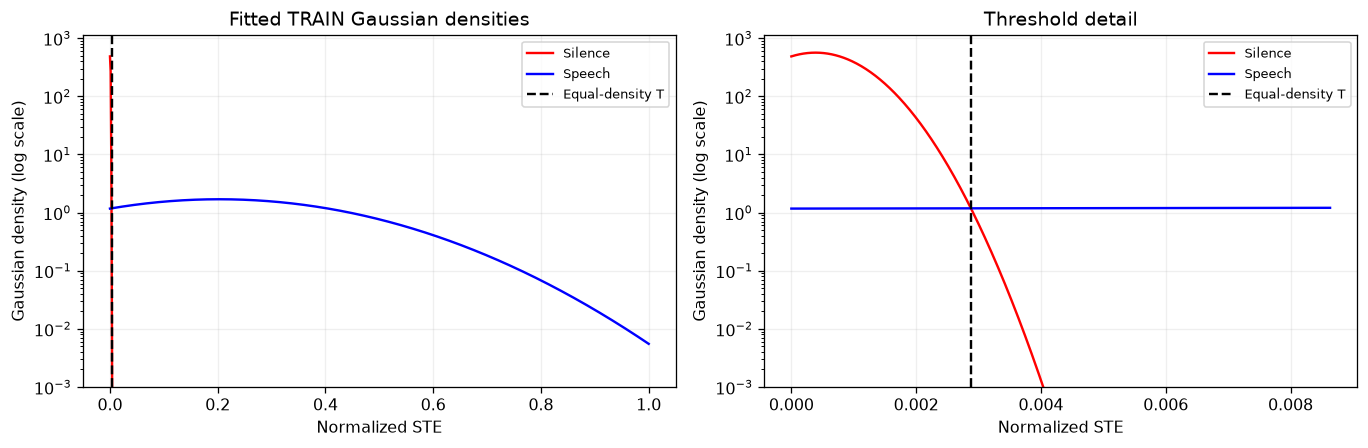

In [15]:
def gaussian_density(value, mean, std):
    """Manual Gaussian density; the effective sigma matches threshold fitting."""
    sigma = max(std, MODEL["sigma_floor"])
    exponent = -((value - mean) ** 2) / (2 * sigma * sigma)
    return math.exp(exponent) / (sigma * math.sqrt(2 * math.pi))

display_table([dict(class_name="Silence", count=MODEL["silence_count"],
                    mean=MODEL["muSil"], population_std=MODEL["stdSil"]),
               dict(class_name="Speech", count=MODEL["speech_count"],
                    mean=MODEL["muSp"], population_std=MODEL["stdSp"])],
              [("class_name", "TRAIN class"), ("count", "Frames"),
               ("mean", "Mean"), ("population_std", "Population std (divide N)")],
              "Actual normalized STE distributions from four TRAIN WAV/LAB pairs")
print(f"Equal-density threshold T={MODEL['threshold']:.12g}; "
      f"rule={MODEL['threshold_rule']}; crossings={MODEL['crossings']}")
figure, axes = plt.subplots(1, 2, figsize=(12, 4))
ranges = [(0.0, 1.0), (0.0, max(MODEL["threshold"] * 3, MODEL["muSil"] + 4 * MODEL["stdSil"]))]
for axis, (lower, upper) in zip(axes, ranges):
    x_values = [lower + (upper - lower) * index / 800 for index in range(801)]
    for label, mean, std, color in (("Silence", MODEL["muSil"], MODEL["stdSil"], "red"),
                                    ("Speech", MODEL["muSp"], MODEL["stdSp"], "blue")):
        y_values = [max(gaussian_density(value, mean, std), 1e-250) for value in x_values]
        axis.plot(x_values, y_values, color=color, label=label)
    axis.axvline(MODEL["threshold"], color="black", linestyle="--", label="Equal-density T")
    axis.set_yscale("log")
    axis.set_ylim(1e-3, max(gaussian_density(MODEL["muSil"], MODEL["muSil"], MODEL["stdSil"]),
                            gaussian_density(MODEL["muSp"], MODEL["muSp"], MODEL["stdSp"])) * 2)
    axis.set(xlabel="Normalized STE", ylabel="Gaussian density (log scale)")
    axis.grid(alpha=0.2)
    axis.legend(fontsize=8)
axes[0].set_title("Fitted TRAIN Gaussian densities")
axes[1].set_title("Threshold detail")
figure.tight_layout()
plt.show()
plt.close(figure)


## Four TEST results

The main table scores the final confirmed regions. START/END columns are in seconds; MAE/RMSE are in milliseconds.


In [16]:
TEST_RESULTS = [predict_and_score(ALGORITHM, record, MODEL) for record in TEST_RECORDS]
ALL_RESULTS = [predict_and_score(ALGORITHM, record, MODEL) for record in ALL_RECORDS]

def metric_rows(records, results):
    return [dict(file=record["name"], split=record["split"], algorithm=ALGORITHM,
                 boundary_MAE_ms=result["metrics"]["mae_ms"], **result["metrics"])
            for record, result in zip(records, results)]

TEST_METRIC_ROWS = metric_rows(TEST_RECORDS, TEST_RESULTS)
ALL_METRIC_ROWS = metric_rows(ALL_RECORDS, ALL_RESULTS)
TEST_SUMMARY = summarize(TEST_METRIC_ROWS)
METRIC_COLUMNS = [
    ("file", "File"), ("split", "Split"),
    ("ground_truth_region_count", "GT regions"), ("predicted_region_count", "Pred regions"),
    ("mae_ms", "Final MAE (ms)"), ("rmse_ms", "RMSE (ms)"), ("status", "Status"),
    ("gt_start_s", "GT START (s)"), ("gt_end_s", "GT END (s)"),
    ("predicted_start_s", "Pred START (s)"), ("predicted_end_s", "Pred END (s)")
]
display_table(TEST_METRIC_ROWS, METRIC_COLUMNS, "Four TEST recordings: final confirmed boundaries")


File,Split,GT regions,Pred regions,Final MAE (ms),RMSE (ms),Status,GT START (s),GT END (s),Pred START (s),Pred END (s)
phone_F2,test,1,1,27.5,32.596012,boundary inside silence,1.02,4.04,1.01,4.085
phone_M2,test,1,1,7.5,7.90569415,OK,0.53,2.52,0.52,2.525
studio_F2,test,1,1,7.50566893,7.90928275,OK,0.77,2.37,0.76,2.36498866
studio_M2,test,1,1,7.49433107,7.90211206,OK,0.45,1.93,0.46,1.93498866


### TEST summary

Mean, median, minimum, maximum, count correctness and highest-error files describe only the four TEST recordings.


In [17]:
display_table(TEST_SUMMARY,
              [("algorithm", "Algorithm"), ("files", "Files"),
               ("evaluated_files", "Defined MAE files"), ("mean_file_mae_ms", "Mean MAE (ms)"),
               ("median_file_mae_ms", "Median (ms)"), ("min_file_mae_ms", "Min (ms)"),
               ("max_file_mae_ms", "Max (ms)"), ("mean_file_rmse_ms", "Mean file RMSE (ms)"),
               ("pooled_endpoint_rmse_ms", "Pooled endpoint RMSE (ms)"),
               ("region_count_correct_files", "Correct counts"),
               ("region_count_incorrect_files", "Incorrect counts"),
               ("mean_frame_f1", "Mean frame F1"), ("top_mae_files", "Highest MAE files"),
               ("evaluation_protocol", "Protocol")],
              "Summary of the four TEST recordings only")


Algorithm,Files,Defined MAE files,Mean MAE (ms),Median (ms),Min (ms),Max (ms),Mean file RMSE (ms),Pooled endpoint RMSE (ms),Correct counts,Incorrect counts,Mean frame F1,Highest MAE files,Protocol
tt3,4,4,12.5,7.50283447,7.49433107,27.5,14.0782752,17.6776704,4,0,0.995870884,phone_F2:27.50ms; studio_F2:7.51ms; phone_M2:7.50ms,training_only_parameters


## All eight input files

This separate table includes TRAIN and TEST with explicit split labels. TRAIN results reuse the model fitted from TRAIN and therefore describe its training fit.


In [18]:
display_table(ALL_METRIC_ROWS, METRIC_COLUMNS, "All eight files: TRAIN and TEST shown explicitly")


File,Split,GT regions,Pred regions,Final MAE (ms),RMSE (ms),Status,GT START (s),GT END (s),Pred START (s),Pred END (s)
phone_F1,train,1,1,2.5,3.53553391,OK,0.53,2.75,0.53,2.745
phone_M1,train,1,1,7.5,10.6066017,OK,0.46,3.52,0.46,3.535
studio_F1,train,1,1,17.4943311,17.6728604,OK,0.68,2.15,0.66,2.16498866
studio_M1,train,1,1,22.4943311,28.5033923,OK,0.87,2.06,0.91,2.06498866
phone_F2,test,1,1,27.5,32.596012,boundary inside silence,1.02,4.04,1.01,4.085
phone_M2,test,1,1,7.5,7.90569415,OK,0.53,2.52,0.52,2.525
studio_F2,test,1,1,7.50566893,7.90928275,OK,0.77,2.37,0.76,2.36498866
studio_M2,test,1,1,7.49433107,7.90211206,OK,0.45,1.93,0.46,1.93498866


## Four inline TEST figures

Red indicates LAB ground truth, blue indicates final predicted regions. Waveform and normalized STE share the same time axis. LOW/HIGH are the actual final confirmation thresholds. Each recording has its own figure cell.


In [19]:
def plot_record(record, result):
    """Show waveform and normalized STE with only GT and FINAL boundaries."""
    features = record["features"]
    diagnostic = result["diagnostic"]
    mae = result["metrics"]["mae_ms"]
    mae_text = f"{mae:.2f} ms" if mae is not None else "N/A"
    figure, axes = plt.subplots(2, 1, figsize=(12.5, 5.5), sharex=True,
                               gridspec_kw={"height_ratios": [1, 1.25]})
    time = [index / record["sample_rate"] for index in range(len(record["samples"]))]
    axes[0].plot(time, record["samples"], color="#444444", linewidth=0.6)
    axes[0].set_ylabel("PCM amplitude")
    axes[1].plot(features["centers"], features["ste_norm"], color="#263238",
                 linewidth=1, label="Normalized STE")
    axes[1].axhline(diagnostic["low_ste_threshold"], color="#008060",
                   linestyle="--", linewidth=1.2, label="LOW")
    axes[1].axhline(diagnostic["high_ste_threshold"], color="#9b6700",
                   linestyle=":", linewidth=1.4, label="HIGH")
    for axis in axes:
        for index, (start, end) in enumerate(result["ground_truth_regions"]):
            axis.axvspan(start, end, color="red", alpha=0.05)
            axis.axvline(start, color="red", linestyle="--", linewidth=1.25,
                        label="GT boundary" if index == 0 else None)
            axis.axvline(end, color="red", linestyle="--", linewidth=1.25)
        for index, (start, end) in enumerate(result["final_regions"]):
            axis.axvspan(start, end, color="#1769d2", alpha=0.11)
            axis.axvline(start, color="#1769d2", linewidth=1.4,
                        label="FINAL predicted boundary" if index == 0 else None)
            axis.axvline(end, color="#1769d2", linewidth=1.4)
        axis.grid(alpha=0.16)
        axis.set_xlim(0, record["duration"])
    axes[1].set_ylabel("Normalized STE")
    axes[1].set_xlabel("Time (s)")
    axes[1].legend(loc="upper right", fontsize=8, ncol=3)
    figure.suptitle(f"{record['name']}.wav | Outer boundary MAE: {mae_text} | "
                   f"{len(result['final_regions'])} speech regions")
    figure.tight_layout()
    plt.show()
    plt.close(figure)


TEST_RECORDS_BY_FILE = {record["name"]: record for record in TEST_RECORDS}
TEST_RESULTS_BY_FILE = {result["file"]: result for result in TEST_RESULTS}


### phone_F2.wav


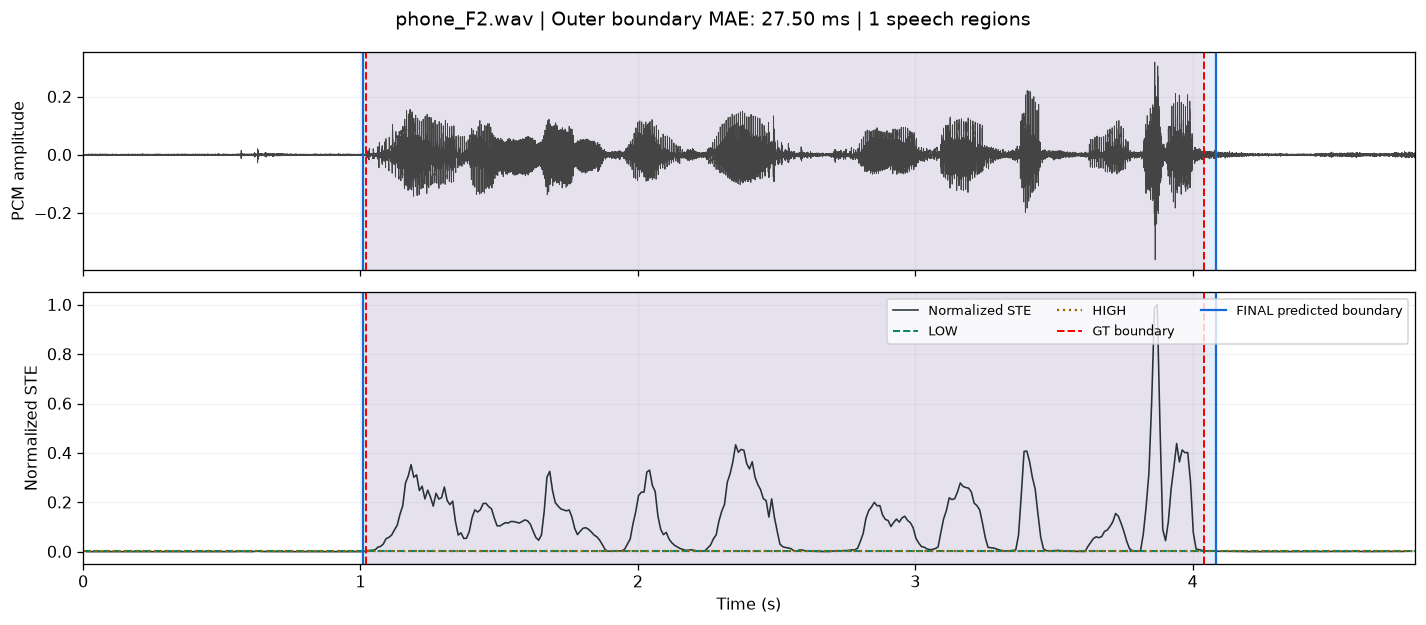

In [20]:
plot_record(TEST_RECORDS_BY_FILE["phone_F2"], TEST_RESULTS_BY_FILE["phone_F2"])


### phone_M2.wav


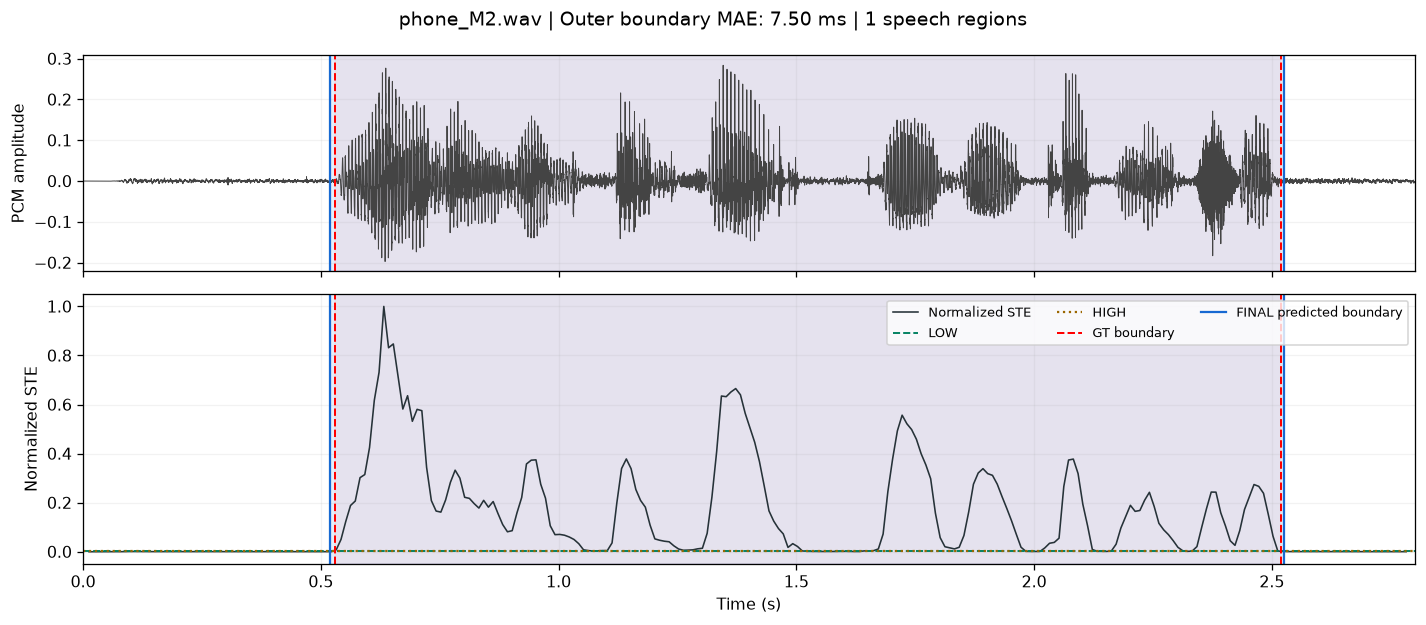

In [21]:
plot_record(TEST_RECORDS_BY_FILE["phone_M2"], TEST_RESULTS_BY_FILE["phone_M2"])


### studio_F2.wav


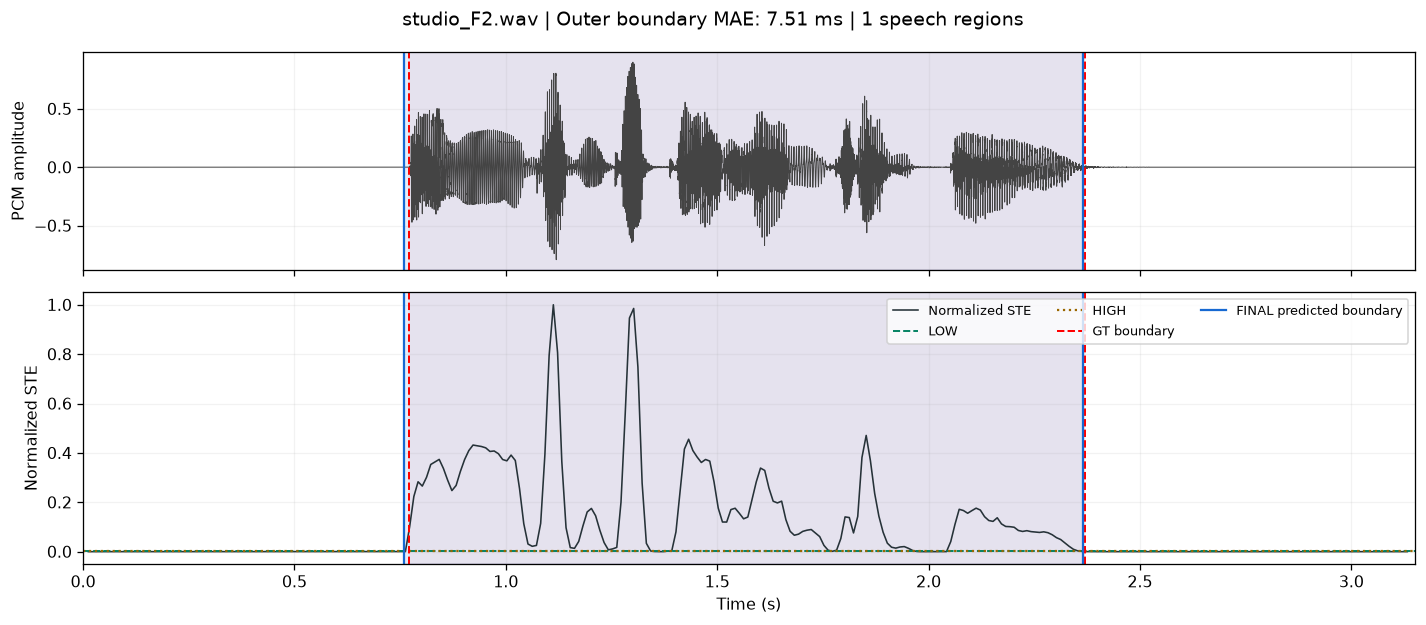

In [22]:
plot_record(TEST_RECORDS_BY_FILE["studio_F2"], TEST_RESULTS_BY_FILE["studio_F2"])


### studio_M2.wav


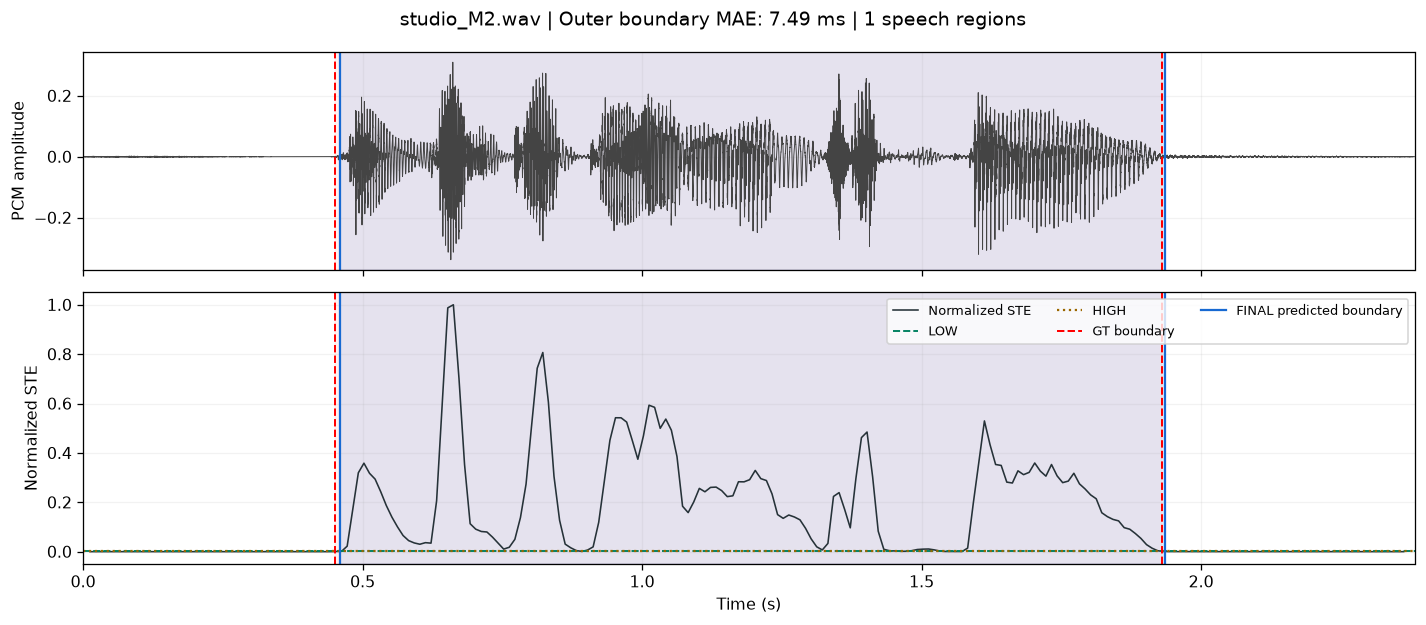

In [23]:
plot_record(TEST_RECORDS_BY_FILE["studio_M2"], TEST_RESULTS_BY_FILE["studio_M2"])


## Optional single-file demonstration

After running all previous cells, call `demo_one_file` with a dataset stem or WAV path. It uses the current model and performs no parameter tuning.


In [24]:
def demo_one_file(filename="phone_F2"):
    """Run one separately supplied WAV using the already fitted MODEL.

    Existing dataset files show LAB scores. An external WAV without a LAB is
    detected using the same fixed model; its reference score is undefined.
    This function never refits or tunes any model parameter.
    """
    requested = Path(filename)
    if not requested.suffix:
        requested = requested.with_suffix(".wav")
    if requested.suffix.lower() != ".wav":
        raise ValueError("Choose a .wav file or a dataset stem.")
    candidates = ([requested] if requested.is_absolute() else
                  [DATA_ROOT / "test" / requested, DATA_ROOT / "train" / requested,
                   Path.cwd() / requested])
    path = next((candidate for candidate in candidates if candidate.is_file()), None)
    if path is None:
        raise FileNotFoundError(f"WAV not found: {requested.name}")
    samples, fs = read_wav(path)
    duration = len(samples) / fs
    lab_path = path.with_suffix(".lab")
    intervals = read_lab(lab_path, duration) if lab_path.is_file() else []
    record = prepare_records([dict(name=path.stem, samples=samples, sample_rate=fs,
                                   duration=duration, intervals=intervals, split="demo")])[0]
    result = predict_and_score(ALGORITHM, record, MODEL)
    rows = metric_rows([record], [result])
    display_table(rows, METRIC_COLUMNS, "Single-file demonstration with fixed MODEL")
    plot_record(record, result)
    return result

# Uncomment to demonstrate a dataset file or provide a WAV path:
# demo_result = demo_one_file("phone_F2")
